# Volt-VAr-Induced Curtailment Detection

Find instances where active-power curtailment is happening *because* the inverter is absorbing
reactive power (Volt-VAr response) and has run out of apparent-power headroom.

## The physics logic

An inverter rated `S_rated` kVA can deliver any combination of active power `P` and reactive
power `Q` as long as they stay inside the **apparent-power circle**: `sqrt(P² + Q²) ≤ S_rated`.

When grid voltage is high (e.g. 240–253 V), AS/NZS 4777.2 requires the inverter to **absorb**
reactive power (negative Q). That absorption consumes part of the apparent-power "budget", so
if the irradiance is strong enough that the inverter *wants* to push out a lot of `P`, it may be
**forced to reduce `P`** to make room for the required `Q`. That reduction is **Volt-VAr-induced
curtailment**, distinct from Volt-Watt curtailment (which only kicks in above 253 V).

## Conditions to find Volt-VAr-induced curtailment timestamps

| # | Condition | Reason |
|---|-----------|-----|
| 1 | Clear-sky day (GHI) | so we know the inverter *could* have produced near its max |
| 2 | Peak solar window (≈11:00 to 13:00) | when `P` is naturally highest. Most likely to hit the limit |
| 3 | `240 < V < 253` | V-VAr absorbing is **active** (Australia A), but V-Watt is **not yet**. Isolates the Volt-VAr effect |
| → | `sqrt(P² + Q²) ≳ S_rated` | inverter is riding its apparent-power limit |

## Two complementary tests

| Method | Uses | Answers |
|--------|------|---------|
| **A: Symptom detection** | measured P, Q, V from `ts` | *Which sites/intervals show the inverter riding its apparent-power limit while absorbing VAr?* |
| **B: Counterfactual quantification** | `all_uncurtailedpv` (GHI model) | *How many kWh of P were actually lost to VAr?* |


###  Some notes
1. **Use `S_99`, not nameplate, for the limit** — the CICCADA pipeline normalises by `S_99`
   (99th-percentile observed apparent power), because the *effective* inverter limit in the data
   is often below the nameplate. Using nameplate would under-count curtailment. We pull both so
   you can compare.
2. **Reactive sign convention.** Everything here assumes **−Q = absorbing**. If your fleet's raw
   `energy_reactive` sign is flipped, the whole detection inverts. We add a sanity-check cell.
3. **"Clear sky" needs a definition.** GHI being *high* isn't enough — it must be *stable*
   (not punching through cloud gaps). We use `GHI / GHI_clear_sky` near 1.0 **and** low local
   variance. The `structured_data` table already has `ghi` and `ghi_cs` so we use their ratio.
4. **Peak-solar window is in local time.** `t_stamp` is UTC — convert to AEST (UTC+10) first,
   or your 11:00–13:00 window lands in the wrong place.
5. **Three-phase sites.** Aggregate P and Q across **all** PV circuits before computing S, and use
   `max(voltage)` across circuits (the worst phase is what triggers the VAr response).


## Notes before running

### 1. Where do `ghi` and `ghi_cs` come from, and how are they calculated?

Both live in **`structured_data`**, the table the GHI/curtailment pipeline is built from
(`ghi_pv_estimator_general/Write_structured_data.ipynb`). Neither is a raw satellite produc. Both are derived:

- **`ghi`**: Bureau of Meteorology / NCI satellite irradiance, natively **10-minute** resolution,
  matched to each site's nearest lat/long grid cell. It is resampled to 5-minute by **duplicating**
  each 10-min reading and shifting the copy +5 minutes (not interpolated). So odd 5-minute
  intervals carry the *same* GHI value as the preceding even one. This means the practical
  temporal resolution of `ghi` is still 10 minutes, not 5.

- **`ghi_cs`** ("clear-sky GHI"): *not* a physical clear-sky model (e.g. Ineichen). It's
  **empirical**: for each site, the pipeline finds the **clearest day per month** at that
  location (lowest summed cloud-type index, `cloud_sum < 60`, peak GHI `> 200`), then for any
  given day it finds the **nearest such clear-sky day** (by calendar distance, ≤45 days). Within
  that reference day, `ghi_cs` at each 5-minute time-of-day bin is the **60th percentile of GHI**
  over a ±3-interval rolling window (`approx_percentile(GHI, 0.6) OVER (... ROWS BETWEEN 3
  PRECEDING AND 3 FOLLOWING)`), computed within continuous data segments (a gap >30 min starts a
  new segment). 
  The same logic builds `P_kw_norm_cs`, the matching clear-sky **power** shape.

So `ghi/ghi_cs` is "how much sun today, relative to the clearest day this site saw nearby in the
calendar". Not an absolute clear-sky physics model. 

This matters for you: a "clear-sky" flag near `ghi/ghi_cs ≈ 1` only means *as clear as the best recent reference day*, which might be an imperfect proxy in persistently overcast regions.


### 2. On three phase inverters

For three-phase sites, the inverter typically
responds to **per-phase** voltage, but our 240–253 V eligibility test uses `max(V)` — the worst
phase. A three-phase site could have one phase at 248 V (V-VAr-eligible) while the other two sit
at 235 V (not eligible), yet our aggregate `P` and `Q` are summed across all three. This is a
known simplification (shared with the rest of the pipeline) — it slightly overstates eligibility
for three-phase sites. If you want a cleaner read on this specific question, set
`PHASE_FILTER = "single"` to restrict to single-phase sites only, where this ambiguity doesn't
arise.


## Setup

In [2]:
from aws_config import *      # aq, dread, s3_ls, databases, tables, describe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pytz

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", font_scale=0.95)

SA  = "solar_analytics"
SAI = "solar_analytics_iceberg"
FIXED_OFFSET = pytz.FixedOffset(600)   # AEST = UTC+10, no DST

# AS/NZS 4777.2:2020 Australia-A Volt-VAr set-points
AS4777 = {
    "VVAR": {
        "V1": 207.0,
        "V2": 220.0,
        "V3": 240.0,
        "V4": 258.0,
        "Q1": 0.44,
        "Q4": 0.60
        },
    "VW":   {
        "V1": 253.0,
        "V2": 260.0,
        "P2": 0.20
        },
    "TOL_FRAC": 0.04,     # established 4% AC-capacity tolerance, used fleet-wide
    "INTERVAL_H": 5/60,
}


In [3]:
# Check whether structured_data has been extended to 2025 ────────────────
# year/month are columns in structured_data (likely partition columns, so this
# should be a relatively cheap aggregate, but it's still a full-table group-by).
ghi_year_check = aq("""
    SELECT year, count(*) AS n_rows, count(DISTINCT site_id) AS n_sites
    FROM structured_data
    GROUP BY year
    ORDER BY year
""", database=SAI)
print(ghi_year_check)

# If 2025 appears with a non-trivial row count, update:
# PARAMS["GHI_YEARS"] = [2024, 2025]

   year     n_rows  n_sites
0  2024  544084502    13967
1  2025  478816145    12737


In [15]:
# Detection parameters
PARAMS = {
    "YEARS":            [2024, 2025],  # years to scan in ts for Method A (multi-year supported)
    "GHI_YEARS":        [2024, 2025],        # years with structured_data / all_uncurtailedpv coverage
    "V_LOW":            240.0,         # lower bound of V-VAr-only band
    "V_HIGH":           253.0,         # upper bound (V-Watt starts here)
    "PEAK_HOUR_START":  11,            # local (AEST) peak-solar window start
    "PEAK_HOUR_END":    13,            #   "          "            window end
    "GHI_CS_RATIO_MIN": 0.85,          # ghi/ghi_cs >= this assumes "clear enough"
                                       #   NOTE: not established elsewhere — tunable, see notes above
    "S_TOL_FRAC":       AS4777["TOL_FRAC"],  # "at the limit" tolerance, consistent with the
                                              #   4% convention used everywhere else (replaces
                                              #   the old, arbitrary S_LIMIT_FRAC=0.97)
    "USE_S99":          True,          # True: use S_99 as the apparent-power limit
                                       #   False: use ac_capacity_kw (nameplate)
    "PHASE_FILTER":     "all",         # "all" | "single" | "three"
                                       #   "all" matches the established 16,148-site cohort
                                       #   definition (1 inverter, up to 3 circuits)
}

print("Setup complete. Parameters:")
for k, v in PARAMS.items():
    print(f"  {k:18s} = {v}")


Setup complete. Parameters:
  YEARS              = [2024, 2025]
  GHI_YEARS          = [2024, 2025]
  V_LOW              = 240.0
  V_HIGH             = 253.0
  PEAK_HOUR_START    = 11
  PEAK_HOUR_END      = 13
  GHI_CS_RATIO_MIN   = 0.85
  S_TOL_FRAC         = 0.04
  USE_S99            = True
  PHASE_FILTER       = all


## 1. Confirm the data

Data needed:
- **`ts`** — raw telemetry (P, Q, V).
- **`meta_up23c`** — `ac_capacity_kw`, `s_99`, circuit polarity, circuit count.
- **`structured_data`** — has `ghi` and `ghi_cs` (see explanation above). Confirmed 2024 only.

Run the check below. If `structured_data` is missing the `ghi` columns, we fall back to a
coarser clear-sky proxy (peak-hour window only, no irradiance check).

In [16]:
# Check structured_data schema for ghi columns
try:
    _sd = aq("SELECT * FROM structured_data LIMIT 1", database=SAI)
    print("structured_data columns:")
    print(list(_sd.columns))
    HAS_GHI = "ghi" in _sd.columns and "ghi_cs" in _sd.columns
    print(f"\nghi + ghi_cs present? {HAS_GHI}")
except Exception as e:
    HAS_GHI = False
    print(f"structured_data not accessible: {e}")
    print("Will fall back to measured-power clear-sky proxy.")

# Confirm meta has the capacity columns
_meta_cols = aq("SELECT * FROM meta_up23c LIMIT 1", database=SAI)
print("\nmeta_up23c has s_99?         ", "s_99" in _meta_cols.columns)
print("meta_up23c has ac_capacity_kw?", "ac_capacity_kw" in _meta_cols.columns)


structured_data columns:
['site_id', 't_stamp', 'actual_day', 'actual_tod', 'v', 'q_kvar_norm', 'p_kw_norm', 's_norm', 'ghi', 'cloud_type', 'cs_day', 'cs_tod', 'p_kw_norm_cs', 'ghi_cs', 'cloud_type_cs', 's_99', 'year', 'month']

ghi + ghi_cs present? True

meta_up23c has s_99?          True
meta_up23c has ac_capacity_kw? True


## 2. Method A: Fleet-wide symptom scan (`ts` + `structured_data`)

This is the **screening** query. It loops over `PARAMS["YEARS"]`, applies the clear-sky GHI
filter only for years present in `PARAMS["GHI_YEARS"]` (falling back to the peak-hour-only proxy
for the rest), and returns **candidate sites ranked by how often they show the symptom**:

> (clear sky if available) **AND** peak solar **AND** 240 < V < 253 **AND** absorbing Q
> **AND** at the apparent-power limit.

It aggregates to the **site level** (all PV circuits combined, per `PHASE_FILTER`) so three-phase
sites are handled per the convention discussed above. Results across years are concatenated and
re-aggregated to one row per site.

In [17]:
def fetch_method_a(year, apply_ghi_filter):
    """
    Run the Method A symptom scan for a single year.
    apply_ghi_filter: if True, joins structured_data and requires ghi/ghi_cs >= GHI_CS_RATIO_MIN.
                      if False, no clear-sky filter is applied (peak-hour-only proxy).
    """
    vv = AS4777["VVAR"]
    P  = PARAMS
    _limit_col = "s_99" if P["USE_S99"] else "ac_capacity_kw"

    # phase filter: restrict by circuit count if requested
    phase_cte   = ""
    phase_join  = ""
    phase_where = ""
    if P["PHASE_FILTER"] != "all":
        op = "= 1" if P["PHASE_FILTER"] == "single" else "> 1"
        phase_cte = (",\n        circuit_counts AS (\n"
                    "            SELECT site_id, count(DISTINCT circuit_id) AS n_circuits\n"
                    "            FROM meta_up23c WHERE is_pv = True\n"
                    "            GROUP BY site_id\n        )")
        phase_join  = "JOIN circuit_counts cc ON sm.site_id = cc.site_id"
        phase_where = f"AND cc.n_circuits {op}"

    # GHI clear-sky filter
    if apply_ghi_filter and HAS_GHI:
        ghi_join   = "JOIN structured_data sd ON d.site_id = sd.site_id AND d.t_stamp = sd.t_stamp"
        ghi_filter = f"AND sd.ghi_cs > 0 AND sd.ghi / sd.ghi_cs >= {P['GHI_CS_RATIO_MIN']}"
    else:
        ghi_join, ghi_filter = "", ""

    sql = f"""
        WITH site_meta AS (
            SELECT DISTINCT site_id, circuit_id, circuit_polarity,
                   ac_capacity_kw, {_limit_col} AS s_limit
            FROM meta_up23c
            WHERE is_pv = True AND {_limit_col} > 0
        ){phase_cte},
        d AS (
            SELECT
                t.circuit_id,
                t.t_stamp,
                sm.site_id,
                sm.s_limit,
                sm.ac_capacity_kw,
                t.voltage,
                t.power * sm.circuit_polarity / 1000.0                  AS P_kW,
                t.energy_reactive * sm.circuit_polarity / 1000.0 * 12   AS Q_kvar
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            {phase_join}
            WHERE t.year = {year} AND t.is_pv = True
              AND t.voltage > {P['V_LOW']} AND t.voltage < {P['V_HIGH']}
              {phase_where}
        ),
        site_interval AS (
            SELECT
                d.site_id,
                d.t_stamp,
                max(d.s_limit)        AS s_limit,
                max(d.ac_capacity_kw) AS ac_capacity_kw,
                max(d.voltage)        AS V_max,
                sum(d.P_kW)           AS P_kW,
                sum(d.Q_kvar)         AS Q_kvar
            FROM d
            {ghi_join}
            WHERE hour(d.t_stamp + interval '10' hour)
                  BETWEEN {P['PEAK_HOUR_START']} AND {P['PEAK_HOUR_END']}
              {ghi_filter}
            GROUP BY d.site_id, d.t_stamp
        ),
        flagged AS (
            SELECT
                site_id, t_stamp, s_limit, ac_capacity_kw, V_max, P_kW, Q_kvar,
                sqrt(P_kW*P_kW + Q_kvar*Q_kvar) AS S_apparent,
                s_limit - sqrt(greatest(s_limit*s_limit - Q_kvar*Q_kvar, 0)) AS P_headroom_lost_kW
            FROM site_interval
            WHERE Q_kvar < 0
              AND sqrt(P_kW*P_kW + Q_kvar*Q_kvar)
                  >= s_limit - {P['S_TOL_FRAC']} * ac_capacity_kw
        )
        SELECT
            site_id,
            count(*)                              AS n_flagged_intervals,
            round(avg(V_max), 1)                  AS avg_V,
            round(avg(P_kW), 2)                    AS avg_P_kW,
            round(avg(Q_kvar), 2)                  AS avg_Q_kvar,
            round(avg(s_limit), 2)                 AS avg_s_limit,
            round(sum(P_headroom_lost_kW) * {AS4777['INTERVAL_H']}, 2) AS est_curtailed_kWh
        FROM flagged
        GROUP BY site_id
    """
    return aq(sql, database=SAI)


# ── Run across all requested years ────────────────────────────────────────
_year_results = []
for _year in PARAMS["YEARS"]:
    _apply_ghi = HAS_GHI and (_year in PARAMS["GHI_YEARS"])
    print(f"Year {_year}: clear-sky GHI filter {'ON' if _apply_ghi else 'OFF (peak-hour proxy only)'}")
    _df = fetch_method_a(_year, apply_ghi_filter=_apply_ghi)
    _df["year"] = _year
    _df["ghi_filtered"] = _apply_ghi
    _year_results.append(_df)

_all_years = pd.concat(_year_results, ignore_index=True)

# re-aggregate across years to one row per site
candidates = (
    _all_years.groupby("site_id")
    .agg(
        n_flagged_intervals=("n_flagged_intervals", "sum"),
        avg_V=("avg_V", "mean"),
        avg_P_kW=("avg_P_kW", "mean"),
        avg_Q_kvar=("avg_Q_kvar", "mean"),
        avg_s_limit=("avg_s_limit", "mean"),
        est_curtailed_kWh=("est_curtailed_kWh", "sum"),
        years_covered=("year", lambda s: sorted(s.unique().tolist())),
    )
    .reset_index()
    .sort_values("n_flagged_intervals", ascending=False)
)

print(f"\nSites showing Volt-VAr-curtailment symptom across {PARAMS['YEARS']}: {len(candidates)}")
candidates.head(20)


Year 2024: clear-sky GHI filter ON
Year 2025: clear-sky GHI filter ON

Sites showing Volt-VAr-curtailment symptom across [2024, 2025]: 7702


,site_id,n_flagged_intervals,avg_V,avg_P_kW,avg_Q_kvar,avg_s_limit,est_curtailed_kWh,years_covered
978,276149647,13038,246.65,7.660,-1.770,7.89,226.78,"[2024, 2025]"
6282,1752460611,11415,243.40,4.910,-0.470,4.99,25.36,"[2024, 2025]"
140,35479265,10947,244.00,4.845,-0.515,4.92,29.03,"[2024, 2025]"
6659,1859863480,10858,248.25,4.565,-1.625,4.91,258.94,"[2024, 2025]"
4199,1178534656,10691,244.80,4.825,-1.050,4.99,107.52,"[2024, 2025]"
2897,808910833,10216,244.40,4.820,-0.640,4.91,40.78,"[2024, 2025]"
2685,749828049,10021,247.95,5.645,-2.000,6.09,297.96,"[2024, 2025]"
6045,1688664334,9967,245.40,4.780,-1.245,4.99,136.22,"[2024, 2025]"
2384,667745389,9861,248.80,4.450,-1.690,4.83,256.17,"[2024, 2025]"
5308,1488814892,9853,244.40,4.880,-0.095,4.92,0.76,"[2024, 2025]"


In [ ]:
# Run once with S_99, once with nameplate, keep both result sets
# PARAMS["USE_S99"] = True
# candidates_s99 = candidates.copy()   # after running Section 2

# PARAMS["USE_S99"] = False
# candidates_nameplate = candidates.copy()  # after running Section 2

In [14]:
print(f"S_99 basis:       {len(candidates_s99):,} sites, "
      f"{candidates_s99['est_curtailed_kWh'].sum():,.0f} kWh")
print(f"Nameplate basis:  {len(candidates_nameplate):,} sites, "
      f"{candidates_nameplate['est_curtailed_kWh'].sum():,.0f} kWh")

S_99 basis:       7,702 sites, 118,105 kWh
Nameplate basis:  4,782 sites, 70,332 kWh


### Columns breakdown

- **`n_flagged_intervals`** — total 5-minute intervals (summed across all requested years) this
  site spent clear-sky (where available), peak-solar, in the 240–253 V band, absorbing VAr, *and*
  riding its apparent-power limit (within the 4% tolerance band). Higher = more affected.
- **`est_curtailed_kWh`** — a **first-order** estimate of energy lost, computed as the
  apparent-power headroom consumed by Q (`s_limit − sqrt(s_limit² − Q²)`) summed over flagged
  intervals. This is an upper bound (it assumes the inverter would have used all that headroom
  for P). Method B refines this with the actual clear-sky potential.
- **`years_covered`** — which of `PARAMS["YEARS"]` contributed flagged intervals for this site.
- **`avg_s_limit`** — the apparent-power limit used (`S_99` or nameplate per `PARAMS["USE_S99"]`).

Sites at the top of this list are your candidates for closer inspection.

## 3 · Reactive sign convention

Everything above assumes **negative Q = absorbing**.

In the 240–253 V band the inverter is *required* to absorb, so on average across the fleet the
measured Q in this band should be negative. **This is a fleet average, not a per-site guarantee**
— plenty of individual inverters don't comply at all (fixed power-factor units that never
respond, or units running an outdated firmware). The check below validates the *sign convention*
itself, not fleet-wide compliance; a positive *average* would mean the sign is flipped, while a
negative average with high variance (lots of individual non-compliant sites) is exactly what
you'd expect from a real, imperfect fleet.

In [18]:
sign_check = aq(f"""
    SELECT
        round(avg(energy_reactive * circuit_polarity / 1000.0 * 12), 3) AS avg_Q_kvar_high_V,
        count(*) AS n
    FROM ts t
    JOIN (SELECT DISTINCT circuit_id, circuit_polarity
          FROM meta_up23c WHERE is_pv = True) m USING (circuit_id)
    WHERE t.year = {PARAMS['YEARS'][0]} AND t.is_pv = True
      AND t.voltage > 245 AND t.voltage < 253
""", database=SAI)

q_avg = sign_check["avg_Q_kvar_high_V"].iloc[0]
print(f"Average Q in 245-253 V band ({PARAMS['YEARS'][0]}): {q_avg} kvar")
if q_avg < 0:
    print("✓ Negative -> absorbing on average, as expected. Sign convention is correct.")
else:
    print("[!] POSITIVE -> sign may be flipped! If so, negate energy_reactive everywhere,")
    print("  OR your fleet genuinely isn't absorbing (inactive Volt-VAr) — investigate.")


Average Q in 245-253 V band (2024): -0.209 kvar
✓ Negative -> absorbing on average, as expected. Sign convention is correct.


### What insights to draw from this, and how to visualise them

A single fleet-average Q tells you the sign convention is right; it doesn't tell you **how
prevalent** non-compliance is, or **where** it concentrates. Two views are more useful for that:

1. **Compliance rate vs voltage** — for each voltage bin, what fraction of intervals show
   `Q < 0`? This should rise from near-zero below 220 V (deadband, Q≈0 is expected, not absorbing)
   toward 100% as voltage climbs past ~245–250 V. A fleet where this curve **plateaus well below
   100%** even at high voltage is telling you a meaningful fraction of inverters are simply
   inactive (fixed-PF) or non-conformant — directly relevant context before you go looking for
   VAr-induced curtailment, since sites that never absorb VAr in the first place can't be
   experiencing VAr-induced curtailment.
2. **Q distribution by voltage bin** (boxplot) — shows not just the compliance rate but the
   *spread*: are non-compliant points clustered near zero (inactive) or scattered in the wrong
   direction (adverse)?

Run on a representative month before scaling to the full fleet — this query can be heavy if run
across all years/sites at once.

In [1]:
# Fleet-wide compliance-by-voltage insight (run on one month)
INSIGHT_YEAR  = PARAMS["YEARS"][0]
INSIGHT_MONTH = 6     # keep to one month to bound the scan

qv_sample = aq(f"""
    SELECT
        avg(t.voltage)                                              AS V,
        sum(t.energy_reactive * m.circuit_polarity) / 1000.0 * 12   AS Q_kvar
    FROM ts t
    JOIN (SELECT DISTINCT circuit_id, circuit_polarity
          FROM meta_up23c WHERE is_pv = True) m
      ON t.circuit_id = m.circuit_id
    WHERE t.year = {INSIGHT_YEAR} AND t.month = {INSIGHT_MONTH} AND t.is_pv = True
      AND t.voltage > 0 AND t.voltage < 300
    GROUP BY t.circuit_id, t.t_stamp
""", database=SAI)

qv_sample = qv_sample[(qv_sample["V"] >= 220) & (qv_sample["V"] <= 260)].copy()
qv_sample["absorbing"] = qv_sample["Q_kvar"] < 0

bin_edges = np.arange(220, 262, 4)
qv_sample["v_bin"] = pd.cut(qv_sample["V"], bins=bin_edges)
bin_summary = (
    qv_sample.groupby("v_bin", observed=True)
    .agg(pct_absorbing=("absorbing", "mean"), n=("absorbing", "size"))
    .reset_index()
)
bin_summary["v_mid"] = bin_summary["v_bin"].apply(lambda x: x.mid).astype(float)
bin_summary["pct_absorbing"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=130)

ax = axes[0]
ax.bar(bin_summary["v_mid"], bin_summary["pct_absorbing"],
       width=3.5, color=sns.color_palette("deep")[0], alpha=0.85)
ax.axhline(100, color="green", lw=1, ls="--", alpha=0.5, label="100% (full compliance)")
ax.axvline(240, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Voltage bin (V)")
ax.set_ylabel("% of intervals absorbing (Q<0)")
ax.set_title(f"Fleet-wide V-VAr compliance rate by voltage\n{INSIGHT_YEAR}-{INSIGHT_MONTH:02d}", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
plot_df = qv_sample[qv_sample["V"].between(225, 258)].copy()
plot_df["v_bin5"] = pd.cut(plot_df["V"], bins=np.arange(225, 260, 5))
sns.boxplot(data=plot_df, x="v_bin5", y="Q_kvar", ax=ax,
           color=sns.color_palette("deep")[0], fliersize=1, linewidth=0.8)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Voltage bin (V)")
ax.set_ylabel("Q (kvar)  [+ supply / − absorb]")
ax.set_title("Reactive power distribution by voltage bin", fontsize=10)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"\nFleet-wide: {qv_sample['absorbing'].mean()*100:.1f}% of all 220-260V intervals absorbing")
print(f"Above 245V only: {qv_sample[qv_sample['V']>245]['absorbing'].mean()*100:.1f}% absorbing")

NameError: name 'PARAMS' is not defined

## 4 · Method B: Counterfactual quantification (uses `all_uncurtailedpv`)

Method A estimates lost energy from apparent-power headroom alone. Method B is more direct: it
compares the **clear-sky potential P** (from the GHI model, stored in `all_uncurtailedpv`)
against the **maximum P the inverter could deliver while absorbing the required Q**:

```
P_max_given_Q = sqrt(S_limit² − Q_required²)
varcurt_kW    = max(0, P_potential − P_max_given_Q)
```

If the uncurtailed potential exceeds what's possible given the VAr absorption, the difference is
VAr-induced curtailment. **Only runs for years in `PARAMS["GHI_YEARS"]`** (currently 2024 only).

### How `all_uncurtailedpv` is calculated

This is the counterfactual engine behind the whole notebook, so it's worth understanding fully.
It's a five-stage pipeline (`ghi_pv_estimator_general` folder):

1. **`Write_structured_data`** builds the per-site, per-5-min feature table: actual power
   (normalised by `S_99`, not nameplate), matched `ghi`/`ghi_cs`, and the clear-sky power shape
   `P_kw_norm_cs` described above.
2. **`split_days`** randomly splits each site's distinct days 80/20 into train/validation
   (day-level, so no leakage within a day).
3. **`model_ghi_norm`** fits, **per site and per 5-minute time-of-day bin**, the regression:
   `P_norm/P_norm_cs = a + b × (ghi/ghi_cs)`. The intercept is **pinned**: `a = 1 − b`, so that on
   a clear-sky day (`ghi/ghi_cs = 1`) the model reproduces the clear-sky reference shape exactly.
   Training only uses clean, uncurtailed observations: `V ≤ 253` (no V-Watt) and
   `P_norm ≥ 1 OR S_norm < 1.001` (no V-VAr curtailment already happening).
4. **`Write_All_uncartailedPV`** applies the model fleet-wide to predict `P_kw_norm_est`, then
   **floors the prediction at the actual measured value**
   (`uncurtailed_P = max(model_prediction, actual) × S_99`) — curtailment can only ever *reduce*
   output, so the counterfactual is never allowed below what was actually measured.
5. A **MAPE < 50% quality gate** (computed separately and read from a CSV of accepted site IDs)
   restricts the final table to sites where the model's accuracy is acceptable — 13,937 sites
   were fitted, with a subset passing this gate.

**Caveat worth carrying forward**: because normalisation uses `S_99` rather than nameplate, sites
that have been persistently curtailed historically have a *depressed* `S_99`, which understates
their true uncurtailed potential — the same caveat applies here as for `S_limit` in Section 0.

In [19]:
# Pick a candidate site from Method A — restrict to a year covered by GHI data
_ghi_eligible = candidates[candidates["years_covered"].apply(
    lambda yrs: any(y in PARAMS["GHI_YEARS"] for y in yrs)
)]
if _ghi_eligible.empty:
    print("No candidate sites have data in a GHI-covered year. Re-run Method A "
          "with a GHI_YEARS year included in PARAMS['YEARS'].")
else:
    TARGET_SITE = int(_ghi_eligible["site_id"].iloc[0])   # top symptom site; change as needed
    METHOD_B_YEAR = PARAMS["GHI_YEARS"][0]                # Method B only runs for GHI years
    print(f"Quantifying Volt-VAr curtailment for site {TARGET_SITE}, year {METHOD_B_YEAR}")

    vv = AS4777["VVAR"]
    P  = PARAMS
    _limit_col = "s_99" if P["USE_S99"] else "ac_capacity_kw"

    varcurt = aq(f"""
        WITH site_meta AS (
            SELECT DISTINCT site_id, circuit_id, circuit_polarity,
                   ac_capacity_kw, {_limit_col} AS s_limit
            FROM meta_up23c
            WHERE is_pv = True AND site_id = {TARGET_SITE}
        ),
        meas AS (
            SELECT
                sm.site_id, t.t_stamp,
                max(sm.s_limit)                                        AS s_limit,
                max(sm.ac_capacity_kw)                                 AS ac_capacity_kw,
                max(t.voltage)                                         AS V_max,
                sum(t.power * sm.circuit_polarity / 1000.0)            AS P_meas_kW,
                sum(t.energy_reactive * sm.circuit_polarity/1000.0*12) AS Q_meas_kvar
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            WHERE t.year = {METHOD_B_YEAR} AND t.is_pv = True
              AND t.voltage > {P['V_LOW']} AND t.voltage < {P['V_HIGH']}
              AND hour(t.t_stamp + interval '10' hour)
                  BETWEEN {P['PEAK_HOUR_START']} AND {P['PEAK_HOUR_END']}
            GROUP BY sm.site_id, t.t_stamp
        ),
        pot AS (
            SELECT site_id, t_stamp, uncurtailed_P AS P_potential_kW
            FROM all_uncurtailedpv
            WHERE site_id = {TARGET_SITE}
        )
        SELECT
            m.t_stamp, m.V_max, m.s_limit, m.ac_capacity_kw,
            m.P_meas_kW, m.Q_meas_kvar,
            p.P_potential_kW,
            sqrt(greatest(m.s_limit*m.s_limit - m.Q_meas_kvar*m.Q_meas_kvar, 0)) AS P_max_given_Q,
            greatest(0,
                p.P_potential_kW
                - sqrt(greatest(m.s_limit*m.s_limit - m.Q_meas_kvar*m.Q_meas_kvar, 0))
            ) AS varcurt_kW
        FROM meas m
        JOIN pot  p ON m.t_stamp = p.t_stamp
        WHERE m.Q_meas_kvar < 0
        ORDER BY m.t_stamp
    """, database=SAI)

    print(f"Intervals analysed: {len(varcurt)}")
    if len(varcurt):
        total_kwh = (varcurt["varcurt_kW"] * AS4777["INTERVAL_H"]).sum()
        print(f"Estimated Volt-VAr curtailment: {total_kwh:.2f} kWh "
              f"(over {METHOD_B_YEAR} clear-sky peak-solar 240-253V intervals)")
        print(f"Intervals with >0 curtailment: {(varcurt['varcurt_kW'] > 0).sum()}")
    varcurt.head(15)


Quantifying Volt-VAr curtailment for site 276149647, year 2024
Intervals analysed: 19402
Estimated Volt-VAr curtailment: 55.12 kWh (over 2024 clear-sky peak-solar 240-253V intervals)
Intervals with >0 curtailment: 5014


## 5 · Visualise a day with Volt-VAr curtailment

Three power traces tell the story for a single day: **apparent power S** (the binding constraint),
**active power P** (what was actually delivered), and **reactive power |Q|** (what's being
absorbed). The violet band marks the 240–253 V eligibility window; the red band marks intervals
where curtailment was actually detected. This pulls a **full day** of telemetry (not just the
eligible-window subset) so you can see the whole generation profile for context.

Plotting 2024-03-27 for site 276149647 (most curtailment events)


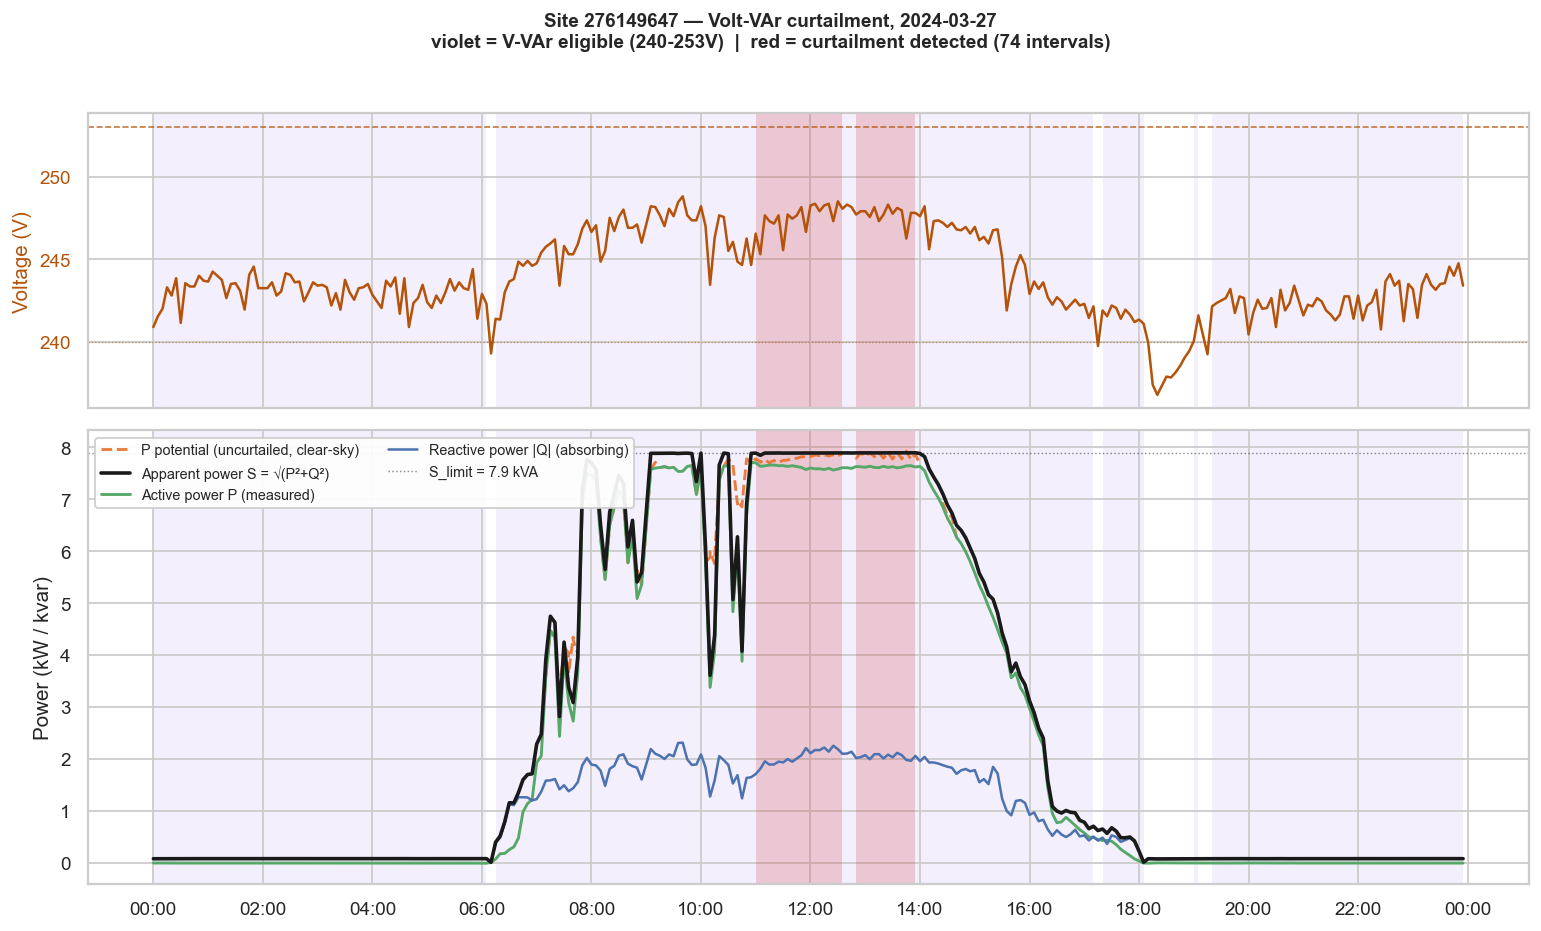

In [20]:
def plot_varcurt_day(site_id, date_str, ac_capacity_kw, s_limit, year=None):
    """
    Full-day plot: voltage panel + 3-power-line panel (S, P, |Q|) with VAr-curtailment
    intervals shaded in red and the V-VAr-eligible band shaded in violet.
    date_str: 'YYYY-MM-DD'
    """
    year = year or PARAMS["GHI_YEARS"][0]
    month = int(date_str.split("-")[1])

    day_df = aq(f"""
        WITH site_meta AS (
            SELECT DISTINCT circuit_id, circuit_polarity
            FROM meta_up23c WHERE is_pv = True AND site_id = {site_id}
        ),
        meas AS (
            SELECT
                t.t_stamp,
                max(t.voltage)                                          AS V,
                sum(t.power * sm.circuit_polarity / 1000.0)             AS P_kW,
                sum(t.energy_reactive * sm.circuit_polarity / 1000.0*12) AS Q_kvar
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            WHERE t.year = {year} AND t.month = {month} AND t.is_pv = True
              AND date(t.t_stamp + interval '10' hour) = date '{date_str}'
            GROUP BY t.t_stamp
        )
        SELECT m.t_stamp, m.V, m.P_kW, m.Q_kvar, u.uncurtailed_P AS P_potential_kW
        FROM meas m
        LEFT JOIN all_uncurtailedpv u
          ON u.site_id = {site_id} AND u.t_stamp = m.t_stamp
        ORDER BY m.t_stamp
    """, database=SAI)

    if day_df.empty:
        print(f"No data for site {site_id} on {date_str}.")
        return

    day_df["t"] = (pd.to_datetime(day_df["t_stamp"])
                    .dt.tz_localize("UTC").dt.tz_convert(FIXED_OFFSET)
                    .dt.tz_localize(None))
    day_df["S_apparent"] = np.sqrt(day_df["P_kW"]**2 + day_df["Q_kvar"]**2)

    V_LOW, V_HIGH = PARAMS["V_LOW"], PARAMS["V_HIGH"]
    eligible = (day_df["V"] > V_LOW) & (day_df["V"] < V_HIGH)
    P_max_given_Q = np.sqrt(np.clip(s_limit**2 - day_df["Q_kvar"]**2, 0, None))
    curtailed = (
        eligible & (day_df["Q_kvar"] < 0) &
        day_df["P_potential_kW"].notna() &
        (day_df["P_potential_kW"] > P_max_given_Q + 0.02)
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), dpi=130, sharex=True,
                             gridspec_kw={"height_ratios": [1.3, 2]})
    pal = sns.color_palette("deep")
    C_V, C_P, C_Q, C_S, C_POT = "#b45309", pal[2], pal[0], "#1a1a1a", "#e8702a"

    for ax in axes:
        ax.fill_between(day_df["t"], 0, 1, where=eligible.values,
                        transform=ax.get_xaxis_transform(),
                        color="#7c3aed", alpha=0.08, linewidth=0, zorder=0)
        ax.fill_between(day_df["t"], 0, 1, where=curtailed.values,
                        transform=ax.get_xaxis_transform(),
                        color="#c62828", alpha=0.20, linewidth=0, zorder=1)

    ax = axes[0]
    ax.plot(day_df["t"], day_df["V"], color=C_V, lw=1.4)
    ax.axhline(V_LOW,  color=C_V, lw=0.7, ls=":",  alpha=0.6)
    ax.axhline(V_HIGH, color=C_V, lw=0.9, ls="--", alpha=0.8)
    ax.set_ylabel("Voltage (V)", color=C_V)
    ax.tick_params(axis="y", colors=C_V)

    ax = axes[1]
    if day_df["P_potential_kW"].notna().any():
        ax.plot(day_df["t"], day_df["P_potential_kW"], color=C_POT, lw=1.6, ls="--",
                alpha=0.9, zorder=3, label="P potential (uncurtailed, clear-sky)")
    ax.plot(day_df["t"], day_df["S_apparent"], color=C_S, lw=2.0, zorder=5,
            label="Apparent power S = √(P²+Q²)")
    ax.plot(day_df["t"], day_df["P_kW"], color=C_P, lw=1.6, zorder=4,
            label="Active power P (measured)")
    ax.plot(day_df["t"], day_df["Q_kvar"].abs(), color=C_Q, lw=1.4, zorder=4,
            label="Reactive power |Q| (absorbing)")
    ax.axhline(s_limit, color=C_S, lw=0.8, ls=":", alpha=0.5,
              label=f"S_limit = {s_limit:.1f} kVA")
    ax.set_ylabel("Power (kW / kvar)")
    ax.legend(fontsize=8, loc="upper left", framealpha=0.92, ncol=2)

    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
    fig.autofmt_xdate(rotation=0, ha="center")

    n_curt = curtailed.sum()
    fig.suptitle(
        f"Site {site_id} — Volt-VAr curtailment, {date_str}\n"
        f"violet = V-VAr eligible ({V_LOW:.0f}-{V_HIGH:.0f}V)  |  "
        f"red = curtailment detected ({n_curt} intervals)",
        fontsize=10.5, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()


# pick the day with the most flagged intervals for TARGET_SITE
if 'varcurt' in dir() and len(varcurt):
    varcurt["t_local"] = (pd.to_datetime(varcurt["t_stamp"])
                          .dt.tz_localize("UTC").dt.tz_convert(FIXED_OFFSET))
    best_date = (varcurt[varcurt["varcurt_kW"] > 0]
                .groupby(varcurt["t_local"].dt.date)["varcurt_kW"]
                .count().idxmax())
    print(f"Plotting {best_date} for site {TARGET_SITE} (most curtailment events)")
    s_limit_val = varcurt["s_limit"].iloc[0]
    plot_varcurt_day(TARGET_SITE, str(best_date), varcurt["ac_capacity_kw"].iloc[0],
                     s_limit_val, year=METHOD_B_YEAR)
else:
    print("Run Section 4 (Method B) first to identify a site and date with curtailment.")


## 6 · Visualising one site: the apparent-power circle

Each flagged interval plotted on the **P–Q plane**, with the apparent-power circle overlaid.
Points sitting **on** the circle (within the established 4% tolerance) are highlighted with a
red ring — these are the intervals where the inverter is genuinely riding its apparent-power
limit while absorbing VAr, the clearest visual signature of VAr-induced curtailment. Colour
encodes voltage, confirming it's the high-V intervals doing it.

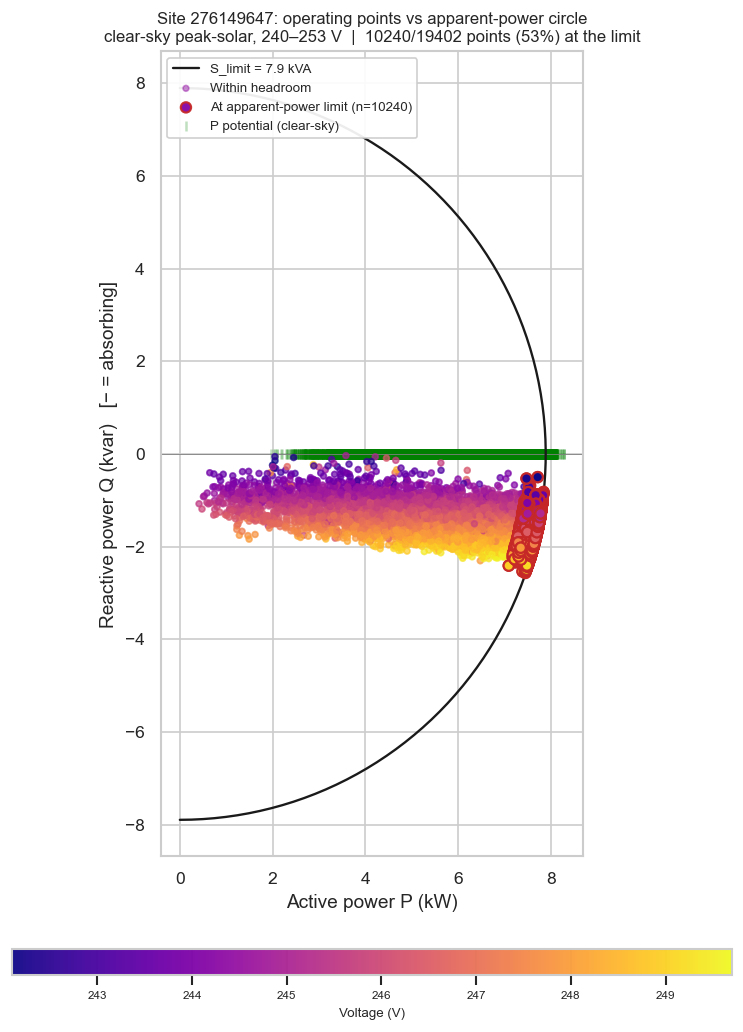

In [21]:
if 'varcurt' not in dir() or len(varcurt) == 0:
    print("No intervals to plot — run Section 4 (Method B) first.")
else:
    S   = varcurt["s_limit"].median()
    cap = varcurt["ac_capacity_kw"].median()
    tol = PARAMS["S_TOL_FRAC"] * cap   # still used to classify points, just not drawn as a band

    S_apparent = np.sqrt(varcurt["P_meas_kW"]**2 + varcurt["Q_meas_kvar"]**2)
    on_circle = S_apparent >= (S - tol)

    # manual axes positioning avoids aspect='equal' breaking gridspec layout
    fig = plt.figure(figsize=(7.5, 8.6), dpi=120)
    ax  = fig.add_axes([0.12, 0.16, 0.80, 0.78])    # main scatter
    cax = fig.add_axes([0.12, 0.045, 0.80, 0.025])  # thin horizontal colorbar strip

    theta = np.linspace(-np.pi/2, np.pi/2, 200)
    ax.plot(S*np.cos(theta), S*np.sin(theta), color="k", lw=1.4, zorder=5,
            label=f"S_limit = {S:.1f} kVA")

    ax.scatter(varcurt.loc[~on_circle, "P_meas_kW"], varcurt.loc[~on_circle, "Q_meas_kvar"],
              c=varcurt.loc[~on_circle, "V_max"], cmap="plasma",
              s=12, alpha=0.45, zorder=3, label="Within headroom")
    sc = ax.scatter(varcurt.loc[on_circle, "P_meas_kW"], varcurt.loc[on_circle, "Q_meas_kvar"],
                    c=varcurt.loc[on_circle, "V_max"], cmap="plasma",
                    s=38, alpha=0.95, zorder=6, edgecolors="#c62828", linewidths=1.3,
                    label=f"At apparent-power limit (n={on_circle.sum()})")

    ax.scatter(varcurt["P_potential_kW"], np.zeros(len(varcurt)),
              marker="|", color="green", s=40, alpha=0.25,
              label="P potential (clear-sky)")

    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("Active power P (kW)")
    ax.set_ylabel("Reactive power Q (kvar)   [− = absorbing]")
    ax.set_title(
        f"Site {TARGET_SITE}: operating points vs apparent-power circle\n"
        f"clear-sky peak-solar, {PARAMS['V_LOW']:.0f}–{PARAMS['V_HIGH']:.0f} V  |  "
        f"{on_circle.sum()}/{len(varcurt)} points ({on_circle.mean()*100:.0f}%) at the limit",
        fontsize=10,
    )
    ax.legend(loc="upper left", fontsize=8, framealpha=0.92)
    ax.set_aspect("equal")

    cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
    cbar.set_label("Voltage (V)", fontsize=8)
    cax.tick_params(labelsize=7)

    plt.show()

## 7 · Fleet summary: how often does this happen, in context

The raw counts from Method A only mean something next to the size of the fleet they're drawn
from. This section adds three pieces of context: the **size of the eligible fleet** (sites that
ever appear in the 240–253V/peak-solar window, regardless of whether they're flagged), the
**total eligible generation** in that window (from `all_uncurtailedpv`, used as the denominator
for "what fraction of potential generation was lost"), and the resulting **% of sites affected**
and **% of eligible generation curtailed**.

In [ ]:
if len(candidates) == 0:
    print("No candidate sites found. Loosen PARAMS (e.g. raise GHI_CS_RATIO_MIN tolerance, "
          "or check S_TOL_FRAC).")
else:
    n_sites_affected = len(candidates)
    total_flagged    = candidates["n_flagged_intervals"].sum()
    total_est_kwh    = candidates["est_curtailed_kWh"].sum()

    # ── fleet-context denominator: total eligible generation potential ────────
    # (same conditions as Method A, but WITHOUT the Q<0 / at-limit restriction —
    #  i.e. every site that was ever clear-sky, peak-solar, 240-253V, summed)
    _ctx_year = PARAMS["GHI_YEARS"][0]
    fleet_context = aq(f"""
        WITH site_meta AS (
            SELECT DISTINCT site_id, circuit_id, circuit_polarity, ac_capacity_kw
            FROM meta_up23c WHERE is_pv = True
        ),
        d AS (
            SELECT t.circuit_id, t.t_stamp, sm.site_id,
                   t.voltage
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            WHERE t.year = {_ctx_year} AND t.is_pv = True
              AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
        ),
        site_interval AS (
            SELECT d.site_id, d.t_stamp, max(d.voltage) AS V_max
            FROM d
            JOIN structured_data sd ON d.site_id = sd.site_id AND d.t_stamp = sd.t_stamp
            WHERE hour(d.t_stamp + interval '10' hour)
                  BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
              AND sd.ghi_cs > 0 AND sd.ghi / sd.ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']}
            GROUP BY d.site_id, d.t_stamp
        )
        SELECT
            count(DISTINCT si.site_id)               AS n_eligible_sites,
            count(*)                                  AS n_eligible_intervals,
            round(sum(u.uncurtailed_P) * {AS4777['INTERVAL_H']}, 1) AS total_potential_kWh
        FROM site_interval si
        LEFT JOIN all_uncurtailedpv u
          ON u.site_id = si.site_id AND u.t_stamp = si.t_stamp
    """, database=SAI)

    n_eligible_sites     = int(fleet_context["n_eligible_sites"].iloc[0])
    total_potential_kwh  = float(fleet_context["total_potential_kWh"].iloc[0] or 0)

    print("="*64)
    print(f"VOLT-VAR CURTAILMENT — FLEET SUMMARY ({PARAMS['YEARS']})")
    print("="*64)
    print(f"Eligible fleet (clear-sky, peak-solar, {PARAMS['V_LOW']:.0f}-{PARAMS['V_HIGH']:.0f}V):")
    print(f"  Sites:                          {n_eligible_sites:,}")
    print(f"  Total eligible potential gen.:   {total_potential_kwh:,.0f} kWh ({_ctx_year} only)")
    print()
    print(f"Sites showing the VAr-curtailment symptom: {n_sites_affected:,} "
          f"({n_sites_affected/n_eligible_sites*100:.1f}% of eligible fleet)")
    print(f"Total flagged intervals:                   {total_flagged:,}")
    print(f"Est. energy curtailed (Method A):           {total_est_kwh:,.1f} kWh")
    if total_potential_kwh > 0:
        print(f"  -> {total_est_kwh/total_potential_kwh*100:.3f}% of total eligible potential generation")
    print(f"Median intervals per affected site:         {candidates['n_flagged_intervals'].median():.0f}")
    print()
    print("Top 10 most-affected sites:")
    print(candidates.head(10)[["site_id","n_flagged_intervals","avg_V",
                                "avg_P_kW","avg_Q_kvar","est_curtailed_kWh"]].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=120)
    axes[0].hist(candidates["n_flagged_intervals"], bins=40,
                color=sns.color_palette("deep")[4], alpha=0.85)
    axes[0].set_xlabel("Flagged intervals per site")
    axes[0].set_ylabel("Number of sites")
    axes[0].set_title(f"Exposure distribution\n({n_sites_affected} affected of {n_eligible_sites} eligible)",
                      fontsize=9.5)

    labels = ["Eligible, not flagged", "Flagged (symptom present)"]
    sizes  = [n_eligible_sites - n_sites_affected, n_sites_affected]
    axes[1].pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90,
               colors=[sns.color_palette("deep")[7], sns.color_palette("deep")[3]])
    axes[1].set_title("Share of eligible fleet affected", fontsize=9.5)

    plt.tight_layout()
    plt.show()

## 8 · Notes, caveats, and next steps

**What changed from the previous version**: replaced the arbitrary `S_LIMIT_FRAC=0.97` with
`S_TOL_FRAC` tied to the established 4% AC-capacity tolerance convention; clarified that
`GHI_CS_RATIO_MIN=0.85` has no precedent elsewhere and is tunable; added multi-year support
(`PARAMS["YEARS"]` vs `PARAMS["GHI_YEARS"]`); added a `PHASE_FILTER` toggle (default: include
both single- and three-phase, matching the established cohort convention); fixed `ghi`/`ghi_cs`
casing; added fleet-wide compliance-by-voltage visualisations, a full-day 3-power-line plot with
curtailment shading, an improved apparent-power-circle plot with on-limit highlighting, and
fleet-context denominators in the summary section.

**Caveats to keep in mind**

1. **`S_99` vs nameplate** — `S_99` is the empirical limit and usually the right choice, but for
   sites that have been curtailing for most of their history, `S_99` is itself depressed, which
   *under*-counts curtailment. Toggle `USE_S99` to compare.
2. **GHI/`all_uncurtailedpv` coverage is `PARAMS["GHI_YEARS"]` only** (currently `[2024]`) — Method
   B and the fleet-context denominator can't run for years outside this list.
3. **`GHI_CS_RATIO_MIN` and `S_TOL_FRAC` are tunable, not derived from the standard** — run a
   sensitivity sweep before quoting a headline number.
4. **The 240–253 V band deliberately excludes the 253–258 V overlap zone** where V-VAr and
   V-Watt act together — in the overlap you can't cleanly attribute curtailment to VAr alone.
5. **Three-phase sites use `max(V)` for eligibility but sum P/Q across phases** — see the phase
   discussion above; set `PHASE_FILTER="single"` if this ambiguity matters for your analysis.
6. **`ghi_cs` is an empirical nearest-clear-sky-day reference, not a physical clear-sky model** —
   it inherits whatever shading/soiling/noise was present on that specific reference day.

**Suggested next steps**

- Run Method A with `USE_S99=True` and `False`; report the range.
- Sensitivity-check `GHI_CS_RATIO_MIN` at 0.80 / 0.85 / 0.90 and confirm the candidate site list
  is stable.
- Cross-tabulate affected sites by **DNSP** and **OEM** — some inverter brands default to
  fixed-PF and won't show this symptom at all, which is itself a finding worth reporting.
- Compare the Volt-VAr-curtailment site list against the Volt-Watt-curtailment list: sites doing
  *both* are losing the most generation at high voltage.


In [ ]:
# ── Fleet funnel diagnostic: trace exactly how many sites survive each filter ─
_ctx_year   = PARAMS["GHI_YEARS"][0]
_limit_col  = "s_99" if PARAMS["USE_S99"] else "ac_capacity_kw"

print("Running funnel diagnostic — 4 separate Athena queries...")

# Step 0: every site with at least one PV circuit
step0 = aq("SELECT count(DISTINCT site_id) AS n FROM meta_up23c WHERE is_pv = True",
          database=SAI)

# Step 1: + valid apparent-power limit (s_99 or ac_capacity_kw > 0)
step1 = aq(f"""
    SELECT count(DISTINCT site_id) AS n FROM meta_up23c
    WHERE is_pv = True AND {_limit_col} > 0
""", database=SAI)

# Step 2: + at least one 5-min interval in the 240-253V band, this year
step2 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True AND {_limit_col} > 0) sm
      ON t.circuit_id = sm.circuit_id
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
""", database=SAI)

# Step 3: + also within the peak-solar window (11:00-13:00 AEST)
step3 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True AND {_limit_col} > 0) sm
      ON t.circuit_id = sm.circuit_id
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
      AND hour(t.t_stamp + interval '10' hour)
          BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
""", database=SAI)

# Step 4: + also clear-sky (ghi/ghi_cs >= GHI_CS_RATIO_MIN) — this is n_eligible_sites
step4 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True AND {_limit_col} > 0) sm
      ON t.circuit_id = sm.circuit_id
    JOIN structured_data sd
      ON sm.site_id = sd.site_id AND t.t_stamp = sd.t_stamp
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
      AND hour(t.t_stamp + interval '10' hour)
          BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
      AND sd.ghi_cs > 0 AND sd.ghi / sd.ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']}
""", database=SAI)

funnel = pd.DataFrame({
    "stage": [
        "0. All is_pv sites",
        f"1. + valid {_limit_col}",
        f"2. + any 5-min interval {PARAMS['V_LOW']:.0f}-{PARAMS['V_HIGH']:.0f}V ({_ctx_year})",
        f"3. + within peak-solar window ({PARAMS['PEAK_HOUR_START']}:00-{PARAMS['PEAK_HOUR_END']}:00)",
        f"4. + clear-sky (ghi/ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']})",
    ],
    "n_sites": [step0["n"].iloc[0], step1["n"].iloc[0], step2["n"].iloc[0],
               step3["n"].iloc[0], step4["n"].iloc[0]],
})
funnel["pct_of_start"] = (funnel["n_sites"] / funnel["n_sites"].iloc[0] * 100).round(1)
funnel["dropped_this_step"] = funnel["n_sites"].diff().fillna(0).astype(int).abs()

print(funnel.to_string(index=False))
print(f"\nFinal n_eligible_sites (step 4) should match the fleet_context query: "
      f"{funnel['n_sites'].iloc[-1]:,}")